# Spatial "Base" Estimates from Historical Soil Analyses

This notebook builds `*_base` (k-NN) and `*_ok` (ordinary kriging) reference columns on the road-safe sample dataset (**file 1**) by spatially interpolating pre-2017 historical soil-analysis records (**file 2**), using two independent spatial estimators in metric (UTM) coordinates, each with its key hyperparameter tuned by cross-validation.

**Inputs**
- File 1 (targets, current): `Morocco_soil_targets_uuid_roadsafe_6ksample_V_310826.csv`
- File 2 (historical analyses, to be date-filtered): `Morocco_soil_analysis_filtered_uuid_roadsafe.csv`

**Variables interpolated from file 2** (rows with `date < 2017-01-01` only):
- `ph_water`
- `organic_matter_pct` × 10 → `organic_matter_g_kg` (unit conversion to match file 1)
- `p2o5_ehangable_olsen_ppm`
- `exchangeable_k2o_ppm`

**Method**
1. Load both CSVs.
2. Filter file 2 to records dated before 2017.
3. Reproject `lon`/`lat` (WGS84, EPSG:4326) to metric UTM coordinates (zone chosen automatically from the data's centroid — Morocco falls in UTM zone 29N).
4. For each variable, cross-validate to pick the k-NN neighbor count (`k`) and the kriging lag-bin count (`nlags`) that minimize CV RMSE — independently per column.
5. Fit a k-NN regressor (tuned `k`, inverse-distance weighting) on the historical UTM coordinates and predict a value at every file-1 point — producing a `<variable>_base` column.
6. Fit an **ordinary kriging** model (spherical variogram, tuned `nlags`) on the same historical UTM coordinates and predict at every file-1 point — producing a `<variable>_ok` column.
7. Both sets of columns are concatenated onto file 1's dataframe.
8. Scatter-plot each file-1 variable against both its `_base` and `_ok` counterparts (same axes, colour-coded by method) to compare the two estimators.

## 1. Imports and configuration

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from pykrige.ok import OrdinaryKriging
from scipy.stats import pearsonr

pd.set_option("display.max_columns", 100)

DATA_DIR = "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815"
FILE1_PATH = f"{DATA_DIR}/Morocco_soil_targets_uuid_roadsafe_6ksample_V_310826.csv"
FILE2_PATH = f"{DATA_DIR}/Morocco_soil_analysis_filtered_uuid_roadsafe.csv"

DATE_CUTOFF = "2017-01-01"

# columns pulled from file 2 -> resulting "<name>_base" (k-NN) / "<name>_ok" (kriging)
# column added to file 1
# (organic matter is unit-converted from % to g/kg before interpolation so that
#  it lines up with file 1's own `organic_matter_g_kg` column)
SOURCE_COLUMNS = [
    "ph_water",
    "organic_matter_g_kg",          # derived: organic_matter_pct * 10
    "p2o5_ehangable_olsen_ppm",
    "exchangeable_k2o_ppm",
]

RANDOM_STATE = 42

# k-NN hyperparameter search (best `k` picked per column by CV RMSE)
CANDIDATE_K = [3, 5, 7, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500]
N_SPLITS_KNN = 10

# ordinary kriging config
VARIOGRAM_MODEL = "spherical"
MAX_KRIGE_POINTS = 2000  # subsample cap: exact OK variogram fitting is O(n^2),
                          # intractable at the full ~28k reference points

# kriging hyperparameter search (best `nlags` picked per column by CV RMSE)
CANDIDATE_NLAGS = [6, 8, 10, 12, 15, 20, 25, 30, 40, 50, 60, 80, 100]
N_SPLITS_OK = 10

## 2. Load file 1 (targets) and file 2 (historical analyses)

In [52]:
df1 = pd.read_csv(FILE1_PATH)
df2 = pd.read_csv(FILE2_PATH)

print(f"file1 (targets):   {df1.shape[0]:,} rows x {df1.shape[1]} cols")
print(f"file2 (analyses):  {df2.shape[0]:,} rows x {df2.shape[1]} cols")

display(df1.head(3))
display(df2.head(3))

file1 (targets):   6,000 rows x 27 cols
file2 (analyses):  47,361 rows x 31 cols


,lon,lat,sand_pct,clay_pct,total_silt_pct,fine_silt_pct,coarse_silt_pct,coarse_element_pct,ph_water,caco3_pct_total,caco3_active_pct,c_e_c_meq_100g,ce_ext1_5_ms_cm,na2o_ppm,cl_ppm,na_meq_100g,c_n_ratio,exchangeable_k2o_ppm,p2o5_ehangable_olsen_ppm,mgo_ppm,iron_ppm_dtpa,mn_ppm_dtpa,cu_ppm_dtpa,zn_ppm_dtpa,b_ppm_hot_water,uuid,organic_matter_g_kg
0,-5.008,33.6698,35.0,29.0,36.0,27.0,9.0,3.0,7.95,29.0,3.9,49.1,0.28,71.0,127.4,0.2,10.2,813.0,392.0,NaN,4.0,27.0,0.5,0.9,0.7,653258ca-8f61-4e3f-91c5-f8f9dde6cb64,56.0
1,-7.851,33.1611,73.0,11.0,16.0,9.0,8.0,1.0,6.24,1.1,0.5,19.6,0.07,91.0,85.5,0.1,16.3,358.0,93.0,330.0,43.6,143.5,1.3,0.6,0.5,63a31fed-b82e-4a9d-a05a-30490f7ac6d9,37.0
2,-7.203,31.8118,49.0,24.0,27.0,20.0,8.0,4.0,8.21,28.0,4.1,31.5,0.47,61.0,120.1,0.2,7.9,201.0,145.0,610.0,4.0,12.3,0.7,0.4,0.5,2a402c07-ca76-4195-9ee1-2b8b98c19b6e,23.0


,lon,lat,date,sand_pct,clay_pct,total_silt_pct,fine_silt_pct,coarse_silt_pct,coarse_element_pct,ph_water,caco3_pct_total,caco3_active_pct,c_e_c_meq_100g,ce_ext1_5_ms_cm,na2o_ppm,cl_ppm,na_meq_100g,c_n_ratio,organic_matter_pct,exchangeable_k2o_ppm,p2o5_ehangable_olsen_ppm,mgo_ppm,cao_ppm,iron_ppm_dtpa,mn_ppm_dtpa,cu_ppm_dtpa,zn_ppm_dtpa,b_ppm_hot_water,depth_from_cm,depth_to_cm,uuid
0,-2.6313,34.8688,2019/12/31,29.0,43.0,29.0,12.0,16.0,4.0,8.5,26.5,10.2,14.6,1.11,892.0,128.3,2.9,10.2,2.3,779.0,6.0,930.0,NaN,1.0,3.7,0.8,0.4,0.5,0,30,3d7b5152-0637-4b7f-80f7-4290c23b86cf
1,-2.2581,34.9366,2019/12/31,27.0,49.0,24.0,11.0,14.0,4.0,8.7,10.2,4.5,22.9,0.24,388.0,5.5,1.2,10.7,2.4,462.0,24.0,NaN,NaN,7.1,11.8,1.6,1.7,0.6,0,30,afa57db7-dcca-48ea-a8c5-112d01adcf57
2,-2.3435,34.9541,2019/06/12,11.0,58.0,31.0,14.0,18.0,2.0,8.4,1.0,NaN,27.2,0.27,324.0,67.3,1.0,10.3,2.3,719.0,71.0,NaN,NaN,8.2,11.6,3.7,3.5,0.7,0,30,65f0eb72-7dca-49d4-b550-0d442119865e


## 3. Filter file 2 to pre-2017 records and prepare the source columns

Only historical analyses dated strictly before 2017-01-01 are used as the spatial reference ("base") pool. `organic_matter_pct` is converted to `organic_matter_g_kg` (×10) so it is on the same scale/unit as file 1's own `organic_matter_g_kg` column.

In [53]:
df2["date"] = pd.to_datetime(df2["date"], errors="coerce")
print("file2 date range:", df2["date"].min().date(), "to", df2["date"].max().date())
print("unparseable dates:", df2["date"].isna().sum())

df2_pre2017 = df2.loc[df2["date"] < DATE_CUTOFF].copy()
print(f"\nrows with date < {DATE_CUTOFF}: {len(df2_pre2017):,} / {len(df2):,}")

# unit conversion: organic matter % -> g/kg
df2_pre2017["organic_matter_g_kg"] = df2_pre2017["organic_matter_pct"] * 10.0

print("\nmissing values in the source columns (pre-2017 subset):")
print(df2_pre2017[SOURCE_COLUMNS].isna().sum())

df2_pre2017[["lon", "lat", "date"] + SOURCE_COLUMNS].describe()

file2 date range: 2011-01-07 to 2020-12-17
unparseable dates: 0

rows with date < 2017-01-01: 27,913 / 47,361

missing values in the source columns (pre-2017 subset):
ph_water                     0
organic_matter_g_kg          0
p2o5_ehangable_olsen_ppm    23
exchangeable_k2o_ppm        10
dtype: int64


,lon,lat,date,ph_water,organic_matter_g_kg,p2o5_ehangable_olsen_ppm,exchangeable_k2o_ppm
count,27913.000000,27913.000000,27913,27913.000000,27913.000000,27890.000000,27903.000000
mean,-6.346064,33.512032,2011-10-28 04:48:13.619460352,7.649147,20.519077,27.380459,298.555317
min,-9.840000,30.751200,2011-01-07 00:00:00,0.460000,0.000000,0.000000,5.000000
25%,-7.726600,32.562900,2011-01-07 00:00:00,7.400000,13.000000,11.000000,156.000000
50%,-6.187800,33.725300,2011-01-07 00:00:00,7.900000,18.000000,20.000000,258.000000
75%,-5.343200,34.459400,2012-01-07 00:00:00,8.150000,25.000000,34.000000,404.000000
max,-1.945000,35.896300,2014-01-07 00:00:00,9.990000,178.000000,448.000000,973.000000
std,1.709826,1.114470,NaN,0.947575,12.996875,28.093533,187.829198


## 4. Reproject lon/lat (WGS84) to metric UTM coordinates

`lat`/`lon` in both files are geographic WGS84 (EPSG:4326) degrees, which are not metric — distances in degrees are not comparable in latitude vs. longitude and are useless for a Euclidean k-NN. We reproject both datasets into the appropriate UTM zone (a metric, locally near-equal-distance projection).

The correct UTM zone is derived automatically from the combined centroid longitude of both datasets (`zone = floor((lon + 180) / 6) + 1`), rather than hard-coded, so it stays correct if the input extent changes. For this dataset it resolves to **UTM zone 29N (EPSG:32629)**, appropriate for Morocco.

In [54]:
# determine the UTM zone from the centroid of ALL points (both files) so both
# datasets are projected into the exact same metric CRS
all_lon = pd.concat([df1["lon"], df2_pre2017["lon"]])
all_lat = pd.concat([df1["lat"], df2_pre2017["lat"]])
mean_lon, mean_lat = all_lon.mean(), all_lat.mean()

utm_zone = int((mean_lon + 180) // 6) + 1
hemisphere_north = mean_lat >= 0
epsg_code = (32600 if hemisphere_north else 32700) + utm_zone

print(f"data centroid: lon={mean_lon:.3f}, lat={mean_lat:.3f}")
print(f"-> UTM zone {utm_zone}{'N' if hemisphere_north else 'S'}  (EPSG:{epsg_code})")

transformer = Transformer.from_crs("EPSG:4326", f"EPSG:{epsg_code}", always_xy=True)


def add_utm_xy(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of df with metric x_utm/y_utm columns from lon/lat."""
    out = df.copy()
    x, y = transformer.transform(out["lon"].to_numpy(), out["lat"].to_numpy())
    out["x_utm"] = x
    out["y_utm"] = y
    return out


df1_utm = add_utm_xy(df1)
df2_utm = add_utm_xy(df2_pre2017)

print("\nfile1 UTM extent (km):")
print((df1_utm[["x_utm", "y_utm"]].describe() / 1000).round(1))

data centroid: lon=-6.440, lat=33.391
-> UTM zone 29N  (EPSG:32629)

file1 UTM extent (km):
        x_utm   y_utm
count     6.0     6.0
mean    697.2  3635.7
std     149.6   148.0
min     384.2  3163.7
25%     574.8  3531.9
50%     719.1  3609.8
75%     809.8  3762.3
max    1138.9  3935.7


## 5. Hyperparameter tuning: best k-NN `k` and best kriging `nlags`

Rather than fixing `k` (k-NN neighbor count) and `nlags` (kriging variogram lag-bin count) arbitrarily, we pick them per column by K-fold cross-validation on the pre-2017 reference pool, minimizing CV RMSE:

- **k-NN**: 5-fold CV over `CANDIDATE_K`, using the full non-null reference pool for that column.
- **Kriging**: 3-fold CV over `CANDIDATE_NLAGS` (fewer folds — an OK fit is far more expensive than a k-NN fit), using the **same `MAX_KRIGE_POINTS` random subsample** that section 7 will use for the final kriging fit, so the tuned `nlags` matches the data it will actually be applied to.

The winning `k`/`nlags` per column (and their CV RMSE) are used directly in the fitting sections below.

In [55]:
def cv_rmse_knn(coords, y, k, n_splits, random_state):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rmses = []
    for train_idx, val_idx in kf.split(coords):
        model = KNeighborsRegressor(n_neighbors=k, weights="distance")
        model.fit(coords[train_idx], y[train_idx])
        pred = model.predict(coords[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y[val_idx], pred)))
    return float(np.mean(rmses))


def cv_rmse_ok(coords, y, nlags, variogram_model, n_splits, random_state):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rmses = []
    for train_idx, val_idx in kf.split(coords):
        try:
            ok_model = OrdinaryKriging(
                coords[train_idx, 0], coords[train_idx, 1], y[train_idx],
                variogram_model=variogram_model, nlags=nlags,
                enable_plotting=False, verbose=False,
            )
            z, _ss = ok_model.execute("points", coords[val_idx, 0], coords[val_idx, 1])
            rmses.append(np.sqrt(mean_squared_error(y[val_idx], np.asarray(z))))
        except Exception:
            continue  # skip a fold/nlags combo the solver can't fit
    return float(np.mean(rmses)) if rmses else np.inf


best_k, best_nlags, train_sub_by_col = {}, {}, {}
tuning_records = []

for col in SOURCE_COLUMNS:
    train = df2_utm.dropna(subset=[col])

    # --- tune k-NN on the full non-null reference pool ---
    coords_full = train[["x_utm", "y_utm"]].to_numpy()
    y_full = train[col].to_numpy()
    knn_scores = {
        k: cv_rmse_knn(coords_full, y_full, k, N_SPLITS_KNN, RANDOM_STATE)
        for k in CANDIDATE_K
    }
    best_k[col] = min(knn_scores, key=knn_scores.get)

    # --- tune kriging nlags on the same subsample the final OK fit will use ---
    train_sub = (
        train.sample(n=MAX_KRIGE_POINTS, random_state=RANDOM_STATE)
        if len(train) > MAX_KRIGE_POINTS
        else train
    )
    train_sub_by_col[col] = train_sub
    coords_sub = train_sub[["x_utm", "y_utm"]].to_numpy()
    y_sub = train_sub[col].to_numpy()
    ok_scores = {
        n: cv_rmse_ok(coords_sub, y_sub, n, VARIOGRAM_MODEL, N_SPLITS_OK, RANDOM_STATE)
        for n in CANDIDATE_NLAGS
    }
    best_nlags[col] = min(ok_scores, key=ok_scores.get)

    tuning_records.append({
        "column": col,
        "best_k": best_k[col],
        "knn_cv_rmse": knn_scores[best_k[col]],
        "best_nlags": best_nlags[col],
        "ok_cv_rmse": ok_scores[best_nlags[col]],
    })
    print(
        f"{col:30s} best_k={best_k[col]:3d} (cv_rmse={knn_scores[best_k[col]]:8.3f})   "
        f"best_nlags={best_nlags[col]:3d} (cv_rmse={ok_scores[best_nlags[col]]:8.3f})"
    )

tuning_df = pd.DataFrame(tuning_records).set_index("column")
tuning_df

ph_water                       best_k= 15 (cv_rmse=   0.487)   best_nlags= 50 (cv_rmse=   0.564)
organic_matter_g_kg            best_k= 15 (cv_rmse=   8.206)   best_nlags= 40 (cv_rmse=   9.827)
p2o5_ehangable_olsen_ppm       best_k= 50 (cv_rmse=  24.682)   best_nlags= 20 (cv_rmse=  28.306)
exchangeable_k2o_ppm           best_k= 30 (cv_rmse= 142.290)   best_nlags= 20 (cv_rmse= 162.054)


,best_k,knn_cv_rmse,best_nlags,ok_cv_rmse
column,,,,
ph_water,15,0.486917,50,0.564338
organic_matter_g_kg,15,8.205974,40,9.826742
p2o5_ehangable_olsen_ppm,50,24.682164,20,28.305564
exchangeable_k2o_ppm,30,142.289609,20,162.054287


## 6. Spatial k-NN interpolation → `<column>_base` features

For each of the 4 source columns, we fit a `KNeighborsRegressor` (using the **cross-validated `best_k[col]`** from section 5, inverse-distance weighting) on the pre-2017 file-2 points in UTM space, then predict a value at every file-1 point. Rows in file 2 missing that specific column are dropped only from that column's fit (not from the others), so each variable uses the maximum available reference data.

The predictions are concatenated onto file 1 as `<column>_base`.

In [56]:
target_coords = df1_utm[["x_utm", "y_utm"]].to_numpy()

df1_with_base = df1_utm.copy()

for col in SOURCE_COLUMNS:
    base_col = f"{col}_base"
    train = df2_utm.dropna(subset=[col])

    knn = KNeighborsRegressor(n_neighbors=best_k[col], weights="distance")
    knn.fit(train[["x_utm", "y_utm"]].to_numpy(), train[col].to_numpy())

    df1_with_base[base_col] = knn.predict(target_coords)

    print(
        f"{base_col:35s} k={best_k[col]:3d}  n_train={len(train):6,d}  "
        f"pred range=[{df1_with_base[base_col].min():.2f}, {df1_with_base[base_col].max():.2f}]"
    )

base_cols = [f"{c}_base" for c in SOURCE_COLUMNS]
display(df1_with_base[["uuid", "lon", "lat"] + SOURCE_COLUMNS + base_cols].head(10))

ph_water_base                       k= 15  n_train=27,913  pred range=[2.41, 8.89]
organic_matter_g_kg_base            k= 15  n_train=27,913  pred range=[4.46, 83.53]
p2o5_ehangable_olsen_ppm_base       k= 50  n_train=27,890  pred range=[6.00, 104.43]
exchangeable_k2o_ppm_base           k= 30  n_train=27,903  pred range=[58.26, 802.40]


,uuid,lon,lat,ph_water,organic_matter_g_kg,p2o5_ehangable_olsen_ppm,exchangeable_k2o_ppm,ph_water_base,organic_matter_g_kg_base,p2o5_ehangable_olsen_ppm_base,exchangeable_k2o_ppm_base
0,653258ca-8f61-4e3f-91c5-f8f9dde6cb64,-5.0080,33.6698,7.95,56.0,392.0,813.0,7.925423,34.342695,60.048522,302.997548
1,63a31fed-b82e-4a9d-a05a-30490f7ac6d9,-7.8510,33.1611,6.24,37.0,93.0,358.0,7.365294,14.357844,17.438775,288.645569
2,2a402c07-ca76-4195-9ee1-2b8b98c19b6e,-7.2030,31.8118,8.21,23.0,145.0,201.0,8.168953,6.640347,25.156998,317.862530
3,3990131b-7c10-4a05-ae04-0966a1e97657,-4.3055,34.0209,8.40,26.0,12.0,645.0,6.990689,20.235385,25.678865,205.638892
4,42f6ebe3-b99f-496a-bb59-0f91fa8e10d5,-9.4767,31.5540,8.66,30.0,280.0,292.0,8.155817,35.373827,10.500478,388.937357
5,dad6120c-aeef-4bd1-9841-1d3960412d95,-2.5156,35.0445,8.70,12.0,61.0,509.0,7.868611,21.579756,15.549038,309.386382
6,ceccde6f-0b1f-4b8b-a8b0-16d6b29c823c,-9.3183,31.9374,8.71,15.0,59.0,245.0,8.329055,11.507464,16.220373,166.573976
7,02cd1a66-a107-41e4-94f9-e07822c2be16,-5.4646,34.9593,8.10,20.0,30.0,65.0,7.203785,24.548724,24.138866,225.496769
8,5c9629a0-c927-44de-b0d8-a528c8c706a1,-6.1352,32.5406,8.80,28.0,75.0,263.0,7.715640,24.047600,21.651006,397.451935
9,268149bd-07aa-46a0-81d9-2959c710fd11,-6.2574,32.4535,8.30,18.0,39.0,285.0,7.518864,15.736109,20.894476,248.294142


## 7. Ordinary kriging interpolation → `<column>_ok` features

Ordinary kriging (OK) is a geostatistical alternative to k-NN: it fits a variogram model describing how spatial correlation decays with distance, then produces a best-linear-unbiased-estimate at each target point (using all reference points, weighted by the fitted spatial structure rather than by raw distance/rank).

Exact OK variogram fitting scales as O(n²) in the number of reference points, which is intractable at the full ~28,000-point pre-2017 pool. For each column we therefore fit on the **same `MAX_KRIGE_POINTS`-capped random subsample (`train_sub_by_col[col]`) used for tuning in section 5** — a spherical variogram model with the **cross-validated `best_nlags[col]`** — then predict at every file-1 point.

The predictions are concatenated onto file 1 as `<column>_ok`. We also print each fitted variogram's sill/range/nugget: a **nugget fraction near 1** means the fit found essentially no exploitable spatial autocorrelation for that variable (at this subsample/lag binning), so OK effectively collapses to the reference-pool mean everywhere — this is a legitimate outcome of the geostatistics, not a bug, and is exactly the kind of divergence from k-NN worth comparing in the scatterplots below.

In [57]:
for col in SOURCE_COLUMNS:
    ok_col = f"{col}_ok"
    train = df2_utm.dropna(subset=[col])
    train_sub = train_sub_by_col[col]  # same subsample tuned against in section 5

    ok_model = OrdinaryKriging(
        train_sub["x_utm"].to_numpy(),
        train_sub["y_utm"].to_numpy(),
        train_sub[col].to_numpy(),
        variogram_model=VARIOGRAM_MODEL,
        nlags=best_nlags[col],
        enable_plotting=False,
        verbose=False,
    )

    z, _ss = ok_model.execute(
        "points", target_coords[:, 0], target_coords[:, 1]
    )
    df1_with_base[ok_col] = np.asarray(z)

    partial_sill, krange, nugget = ok_model.variogram_model_parameters
    nugget_frac = nugget / (partial_sill + nugget)

    print(
        f"{ok_col:35s} nlags={best_nlags[col]:3d}  n_train={len(train_sub):6,d} (of {len(train):,} available)  "
        f"pred range=[{df1_with_base[ok_col].min():.2f}, {df1_with_base[ok_col].max():.2f}]"
    )
    print(
        f"{'':35s} variogram: sill={partial_sill:.3g}  range={krange:,.0f} m  "
        f"nugget={nugget:.3g}  nugget_fraction={nugget_frac:.2f}"
        + ("  <- ~pure nugget: no detected spatial structure, OK ~= mean" if nugget_frac > 0.98 else "")
    )

ok_cols = [f"{c}_ok" for c in SOURCE_COLUMNS]
display(df1_with_base[["uuid", "lon", "lat"] + SOURCE_COLUMNS + ok_cols].head(10))

ph_water_ok                         nlags= 50  n_train= 2,000 (of 27,913 available)  pred range=[2.78, 8.45]
                                    variogram: sill=0.342  range=42,672 m  nugget=0.226  nugget_fraction=0.40
organic_matter_g_kg_ok              nlags= 40  n_train= 2,000 (of 27,913 available)  pred range=[12.83, 27.60]
                                    variogram: sill=91.9  range=516 m  nugget=49  nugget_fraction=0.35
p2o5_ehangable_olsen_ppm_ok         nlags= 20  n_train= 2,000 (of 27,890 available)  pred range=[17.48, 54.93]
                                    variogram: sill=48.4  range=60,585 m  nugget=731  nugget_fraction=0.94
exchangeable_k2o_ppm_ok             nlags= 20  n_train= 2,000 (of 27,903 available)  pred range=[181.72, 433.27]
                                    variogram: sill=5.57e+03  range=447,677 m  nugget=3e+04  nugget_fraction=0.84


,uuid,lon,lat,ph_water,organic_matter_g_kg,p2o5_ehangable_olsen_ppm,exchangeable_k2o_ppm,ph_water_ok,organic_matter_g_kg_ok,p2o5_ehangable_olsen_ppm_ok,exchangeable_k2o_ppm_ok
0,653258ca-8f61-4e3f-91c5-f8f9dde6cb64,-5.0080,33.6698,7.95,56.0,392.0,813.0,7.897157,20.087935,37.612943,362.212303
1,63a31fed-b82e-4a9d-a05a-30490f7ac6d9,-7.8510,33.1611,6.24,37.0,93.0,358.0,7.189277,20.087935,33.063277,306.258409
2,2a402c07-ca76-4195-9ee1-2b8b98c19b6e,-7.2030,31.8118,8.21,23.0,145.0,201.0,7.544019,20.087935,27.864636,347.236301
3,3990131b-7c10-4a05-ae04-0966a1e97657,-4.3055,34.0209,8.40,26.0,12.0,645.0,7.300050,20.087935,54.753785,384.328873
4,42f6ebe3-b99f-496a-bb59-0f91fa8e10d5,-9.4767,31.5540,8.66,30.0,280.0,292.0,7.951953,20.087935,19.417330,315.037279
5,dad6120c-aeef-4bd1-9841-1d3960412d95,-2.5156,35.0445,8.70,12.0,61.0,509.0,7.890928,20.087935,22.424723,382.154592
6,ceccde6f-0b1f-4b8b-a8b0-16d6b29c823c,-9.3183,31.9374,8.71,15.0,59.0,245.0,8.201796,20.087935,18.415829,272.252162
7,02cd1a66-a107-41e4-94f9-e07822c2be16,-5.4646,34.9593,8.10,20.0,30.0,65.0,7.414993,20.087935,26.190612,238.097149
8,5c9629a0-c927-44de-b0d8-a528c8c706a1,-6.1352,32.5406,8.80,28.0,75.0,263.0,7.722833,20.087935,30.108109,316.019075
9,268149bd-07aa-46a0-81d9-2959c710fd11,-6.2574,32.4535,8.30,18.0,39.0,285.0,7.646240,20.087935,27.764456,306.340180


## 8. Resulting dataframe

`df1_with_base` is file 1's dataframe with the four k-NN `_base` columns, the four kriging `_ok` columns (plus the intermediate `x_utm`/`y_utm` metric coordinates), all concatenated on.

In [58]:
print(f"df1_with_base shape: {df1_with_base.shape[0]:,} rows x {df1_with_base.shape[1]} cols")
print("\nk-NN columns added:", base_cols)
print("kriging columns added:", ok_cols)
df1_with_base[base_cols + ok_cols].describe()

df1_with_base shape: 6,000 rows x 37 cols

k-NN columns added: ['ph_water_base', 'organic_matter_g_kg_base', 'p2o5_ehangable_olsen_ppm_base', 'exchangeable_k2o_ppm_base']
kriging columns added: ['ph_water_ok', 'organic_matter_g_kg_ok', 'p2o5_ehangable_olsen_ppm_ok', 'exchangeable_k2o_ppm_ok']


,ph_water_base,organic_matter_g_kg_base,p2o5_ehangable_olsen_ppm_base,exchangeable_k2o_ppm_base,ph_water_ok,organic_matter_g_kg_ok,p2o5_ehangable_olsen_ppm_ok,exchangeable_k2o_ppm_ok
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,7.786792,19.768903,25.708153,310.008350,7.642061,20.082121,27.781690,306.397904
std,0.701545,10.576092,10.831145,105.387413,0.583265,0.248750,5.691592,52.584712
min,2.408468,4.461524,6.000000,58.255761,2.775787,12.833898,17.476652,181.724170
25%,7.650701,13.734258,18.902476,224.175909,7.547804,20.087935,23.666214,274.425583
50%,7.963368,19.263496,24.182322,309.950836,7.673848,20.087935,27.680358,309.161429
75%,8.132180,23.630810,29.201859,397.496725,7.924087,20.087935,29.563186,347.479490
max,8.887661,83.534916,104.427432,802.395429,8.454593,27.597671,54.929953,433.273428


## 9. Scatterplots: file-1 measured value vs. k-NN `_base` and kriging `_ok` estimates

Each panel plots one file-1 column on the x-axis, and **both** spatial estimates on the same y-axis — k-NN (`_base`) and ordinary kriging (`_ok`) — differentiated by colour, with the 1:1 line (perfect agreement) and each method's Pearson r annotated.

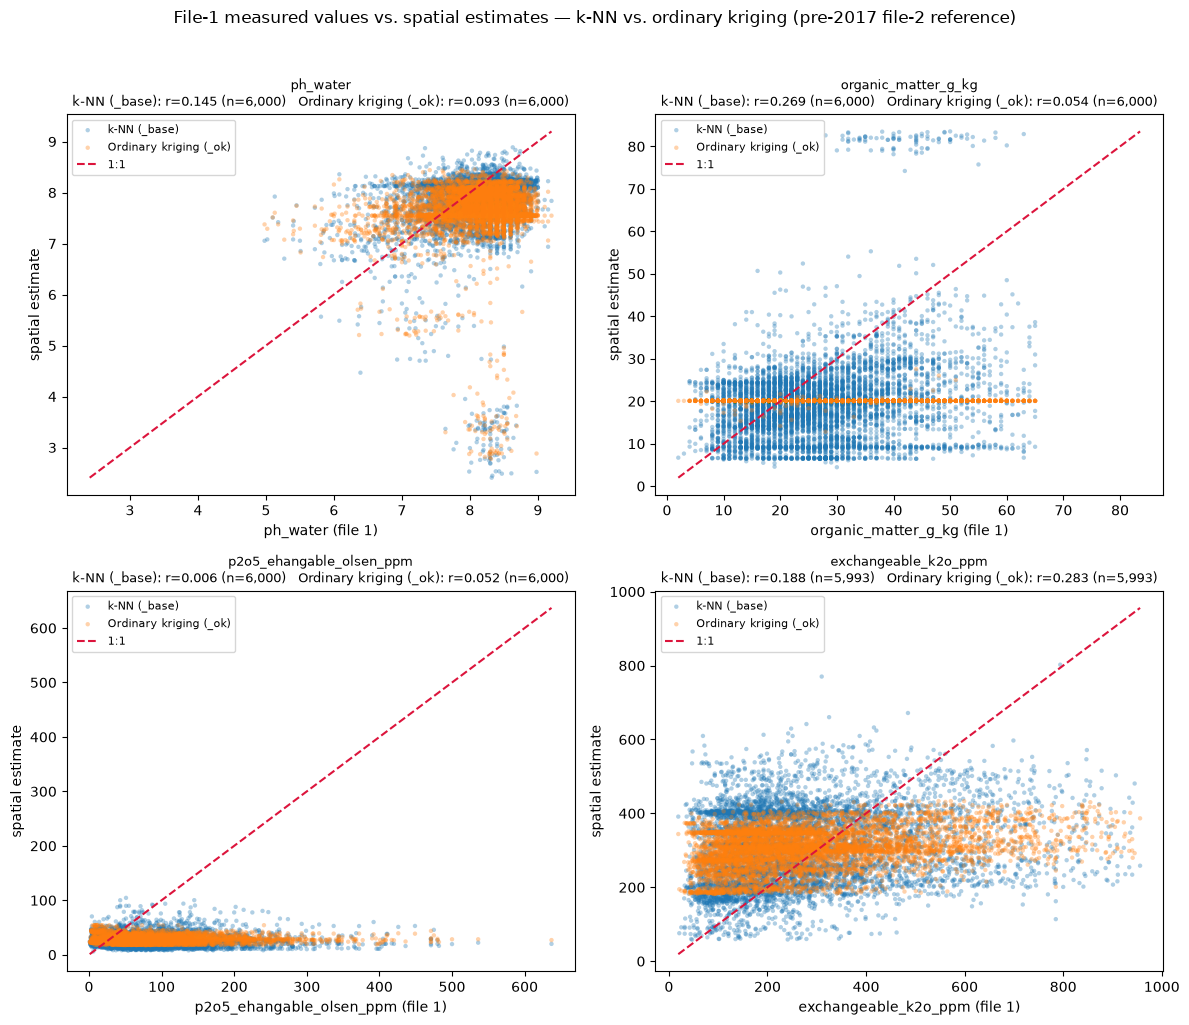

In [59]:
METHOD_STYLE = {
    "base": {"label": "k-NN (_base)", "color": "tab:blue"},
    "ok": {"label": "Ordinary kriging (_ok)", "color": "tab:orange"},
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flat, SOURCE_COLUMNS):
    lo, hi = np.inf, -np.inf
    r_by_method = {}

    for suffix, style in METHOD_STYLE.items():
        est_col = f"{col}_{suffix}"
        pair = df1_with_base[[col, est_col]].dropna()
        x, y = pair[col].to_numpy(), pair[est_col].to_numpy()

        r, _ = pearsonr(x, y)
        r_by_method[style["label"]] = (r, len(pair))

        ax.scatter(
            x, y, s=10, alpha=0.35, edgecolors="none",
            color=style["color"], label=style["label"],
        )
        lo, hi = min(lo, x.min(), y.min()), max(hi, x.max(), y.max())

    ax.plot([lo, hi], [lo, hi], color="crimson", lw=1.5, ls="--", label="1:1")

    ax.set_xlabel(f"{col} (file 1)")
    ax.set_ylabel("spatial estimate")
    subtitle = "   ".join(f"{lbl}: r={r:.3f} (n={n:,})" for lbl, (r, n) in r_by_method.items())
    ax.set_title(f"{col}\n{subtitle}", fontsize=9)
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle(
    "File-1 measured values vs. spatial estimates — k-NN vs. ordinary kriging "
    "(pre-2017 file-2 reference)",
    y=1.02,
)
fig.tight_layout()
plt.show()

## 10. Export: file 1 + k-NN `_base` columns

Concatenate file 1's original columns with just the four k-NN `_base` estimates (kriging `_ok` columns and the intermediate `x_utm`/`y_utm` are left out of the export) and write the result to a new CSV in the **same folder as the input files**, named after file 1 with a `_base` suffix.

In [60]:
import os

df1_export = df1_with_base[list(df1.columns) + base_cols].copy()

file1_stem, file1_ext = os.path.splitext(os.path.basename(FILE1_PATH))
export_path = os.path.join(DATA_DIR, f"{file1_stem}_base{file1_ext}")

df1_export.to_csv(export_path, index=False)

print(f"exported {df1_export.shape[0]:,} rows x {df1_export.shape[1]} cols -> {export_path}")
display(df1_export.head(3))

exported 6,000 rows x 31 cols -> /home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_targets_uuid_roadsafe_6ksample_V_310826_base.csv


,lon,lat,sand_pct,clay_pct,total_silt_pct,fine_silt_pct,coarse_silt_pct,coarse_element_pct,ph_water,caco3_pct_total,caco3_active_pct,c_e_c_meq_100g,ce_ext1_5_ms_cm,na2o_ppm,cl_ppm,na_meq_100g,c_n_ratio,exchangeable_k2o_ppm,p2o5_ehangable_olsen_ppm,mgo_ppm,iron_ppm_dtpa,mn_ppm_dtpa,cu_ppm_dtpa,zn_ppm_dtpa,b_ppm_hot_water,uuid,organic_matter_g_kg,ph_water_base,organic_matter_g_kg_base,p2o5_ehangable_olsen_ppm_base,exchangeable_k2o_ppm_base
0,-5.008,33.6698,35.0,29.0,36.0,27.0,9.0,3.0,7.95,29.0,3.9,49.1,0.28,71.0,127.4,0.2,10.2,813.0,392.0,NaN,4.0,27.0,0.5,0.9,0.7,653258ca-8f61-4e3f-91c5-f8f9dde6cb64,56.0,7.925423,34.342695,60.048522,302.997548
1,-7.851,33.1611,73.0,11.0,16.0,9.0,8.0,1.0,6.24,1.1,0.5,19.6,0.07,91.0,85.5,0.1,16.3,358.0,93.0,330.0,43.6,143.5,1.3,0.6,0.5,63a31fed-b82e-4a9d-a05a-30490f7ac6d9,37.0,7.365294,14.357844,17.438775,288.645569
2,-7.203,31.8118,49.0,24.0,27.0,20.0,8.0,4.0,8.21,28.0,4.1,31.5,0.47,61.0,120.1,0.2,7.9,201.0,145.0,610.0,4.0,12.3,0.7,0.4,0.5,2a402c07-ca76-4195-9ee1-2b8b98c19b6e,23.0,8.168953,6.640347,25.156998,317.862530
